In [31]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")


In [32]:
df.shape

(1000, 9)

In [33]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [34]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [36]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [37]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [5]:
df.mean(numeric_only=True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [10]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [11]:
df.mode()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-05-16,CUST001,Female,43.0,Clothing,4.0,50.0,50.0
1,2,NaN,CUST002,NaN,64.0,NaN,NaN,NaN,NaN
2,3,NaN,CUST003,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,CUST004,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,CUST005,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
995,996,NaN,CUST995,NaN,NaN,NaN,NaN,NaN,NaN
996,997,NaN,CUST996,NaN,NaN,NaN,NaN,NaN,NaN
997,998,NaN,CUST997,NaN,NaN,NaN,NaN,NaN,NaN
998,999,NaN,CUST998,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

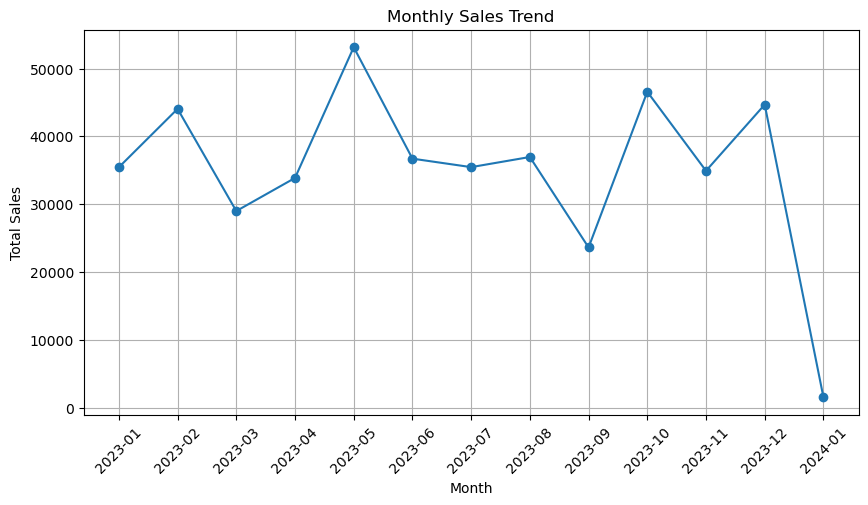

In [29]:
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Observation

* Sales fluctuated throughout the year, with no consistent upward or downward trend.
* May 2023 recorded the highest monthly sales (around 53,000), while September 2023 had the lowest sales among the complete months.
* Sales recovered strongly in October and December, indicating periods of higher customer demand.
* January 2024 shows extremely low sales because the dataset likely contains only partial data for that month. This value should not be used for trend analysis.

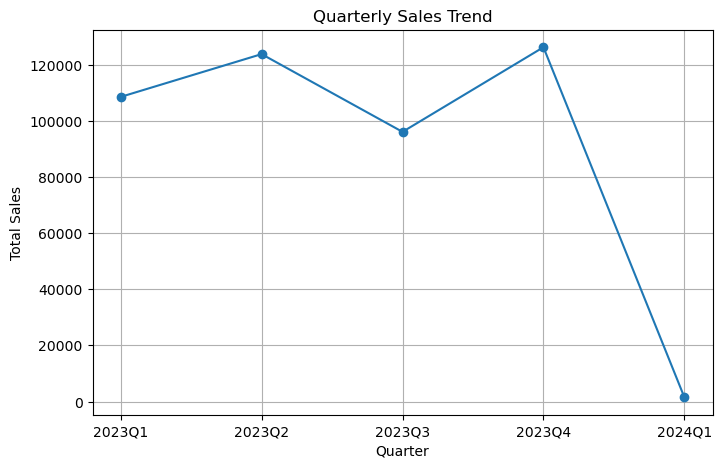

In [8]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

quarterly_sales.index = quarterly_sales.index.astype(str)

plt.figure(figsize=(8,5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Observation

* Q4 (October–December 2023) achieved the highest total sales, indicating strong business performance during the final quarter.
* Q3 (July–September 2023) recorded the lowest sales among the complete quarters, suggesting reduced customer demand.
* Sales improved significantly from Q3 to Q4, indicating a strong recovery toward the end of the year.
* Q1 2024 has very low sales because it contains only January data, making it an incomplete quarter and not directly comparable with the 2023 quarters.

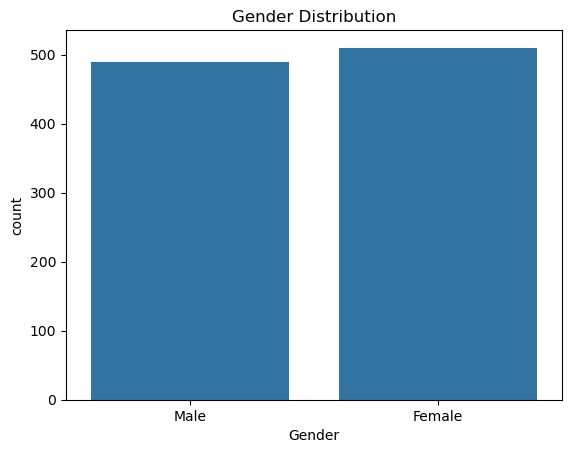

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()

Observation

* The dataset contains a nearly equal number of male and female customers.
* Female customers are slightly more than male customers, indicating a balanced customer base.
* Since both genders contribute significantly, marketing strategies should be designed to appeal to both groups equally.

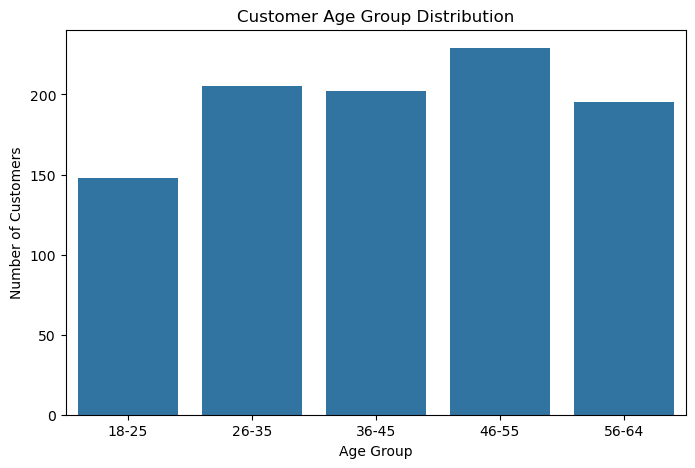

In [30]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age Group')
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

Observation 

* Customers aged 26–35 years represent the largest customer segment.
* Customers aged 56–64 years make up the smallest segment.
* The company should focus marketing campaigns and promotional offers on the most active age group while exploring strategies to attract older customers.

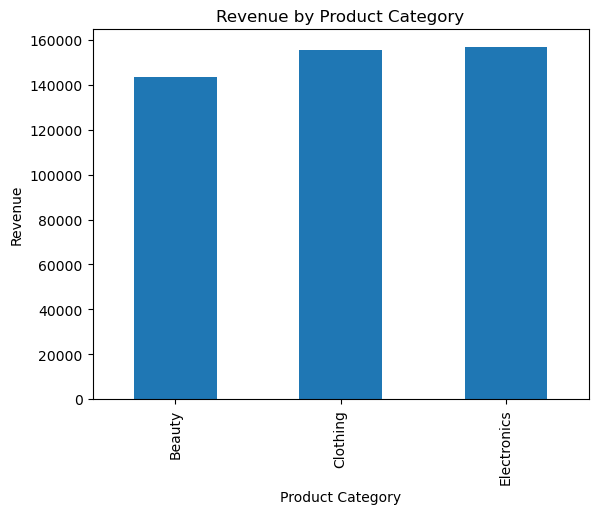

In [25]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

category_sales.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

Observation

* Electronics generated the highest total revenue among all product categories.
* Clothing recorded the second-highest revenue, while Beauty generated the lowest revenue.
* The revenue difference between the categories is relatively small, indicating that all three categories contribute significantly to overall sales.
* The business should continue promoting Electronics while exploring strategies to increase sales in the Beauty category.

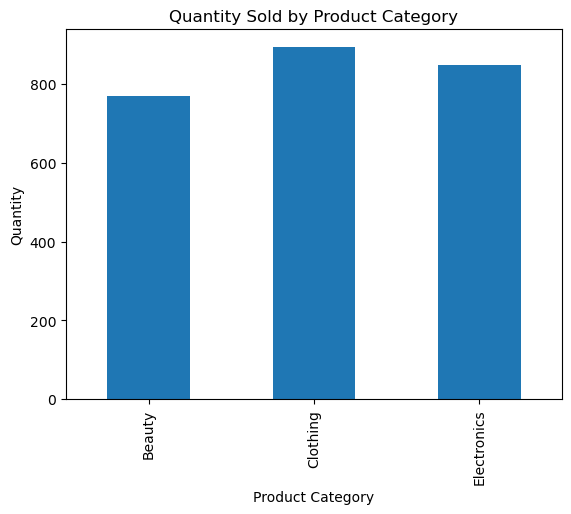

In [26]:
category_quantity = df.groupby("Product Category")["Quantity"].sum()

category_quantity.plot(kind="bar")
plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.show()

In [ ]:
Observation

* Clothing had the highest quantity of items sold, indicating strong customer demand.
* Electronics ranked second in terms of quantity sold, followed by Beauty.
* Although Clothing sold the most units, Electronics generated slightly higher revenue, suggesting that electronic products have a higher average selling price.
* The company should maintain adequate inventory for Clothing products and continue focusing on Electronics for higher revenue generation.

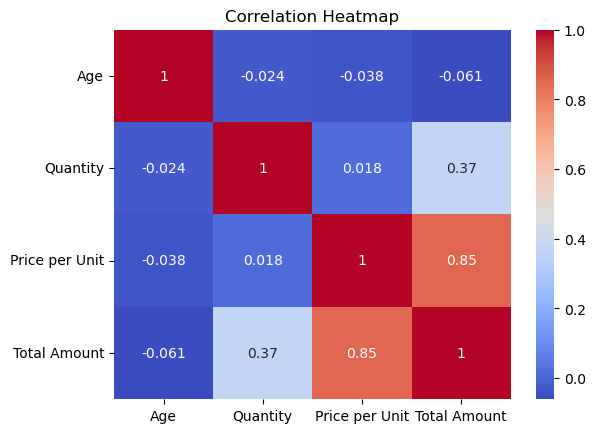

In [27]:
corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Observation

* Price per Unit and Total Amount show a strong positive correlation (0.85), indicating that higher-priced products contribute significantly to higher revenue.
* Quantity has a moderate positive correlation (0.37) with Total Amount, suggesting that purchasing more items increases the total purchase value.
* Age has a very weak correlation with Quantity, Price per Unit, and Total Amount, indicating that customer age has little influence on purchasing behaviour in this dataset.
* Overall, Price per Unit has a greater impact on total revenue than customer age.

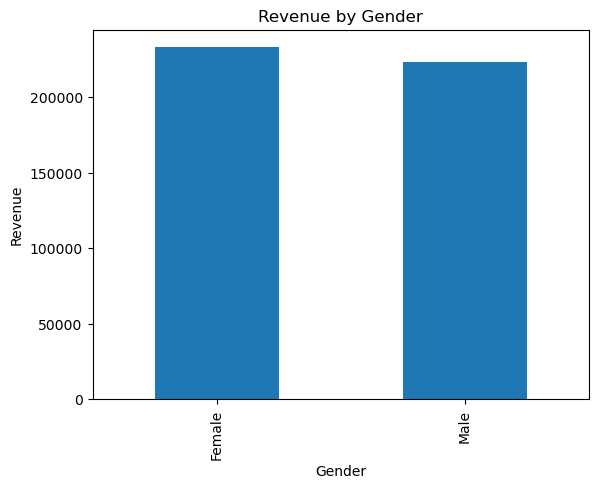

In [28]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

gender_sales.plot(kind="bar")
plt.title("Revenue by Gender")
plt.ylabel("Revenue")
plt.show()

Observation

* Female customers generated slightly higher total revenue than male customers.
* The difference in revenue between the two genders is relatively small, indicating balanced purchasing behaviour.
* Since both genders contribute significantly to sales, the business should continue offering products and marketing campaigns that appeal to both customer segments.

Business Recommendations

1. Increase inventory for Electronics since it generates the highest revenue and contributes significantly to overall sales.
2. Maintain sufficient stock for Clothing products, as they have the highest sales volume and consistent customer demand.
3. Introduce promotional offers for Beauty products to improve their revenue and sales performance.
4. Focus marketing campaigns during high-performing periods (such as Q4) to maximize revenue and customer engagement.